# Results: Order Buyout Prediction

In [22]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

sns.set_style("whitegrid")
DATA_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")
RAW_DATA = Path("../data/raw/dataset_2025-03-01_2026-03-29_external.csv")

In [23]:
train_df = pd.read_parquet(DATA_DIR / "train.parquet")
test_df = pd.read_parquet(DATA_DIR / "test.parquet")
X_train = train_df.drop(columns=["target"])
y_train = train_df["target"]
X_test = test_df.drop(columns=["target"])
y_test = test_df["target"]
with open(MODELS_DIR / "catboost_model.pkl", "rb") as f:
    model = pickle.load(f)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(f"Buyout rate: Train={y_train.mean():.1%}, Test={y_test.mean():.1%}")

Train: 13740, Test: 3435
Buyout rate: Train=82.2%, Test=82.2%


## Model Comparison

In [24]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)
metrics = {
    "AUC-ROC": roc_auc_score(y_test, y_pred_proba),
    "F1": f1_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
}
baseline = {"AUC-ROC": 0.636, "F1": 0.671, "Precision": 0.874, "Recall": 0.545}
print(pd.DataFrame({"CatBoost": metrics, "LogReg": baseline}).round(3))

           CatBoost  LogReg
AUC-ROC       0.967   0.636
F1            0.953   0.671
Precision     0.978   0.874
Recall        0.929   0.545


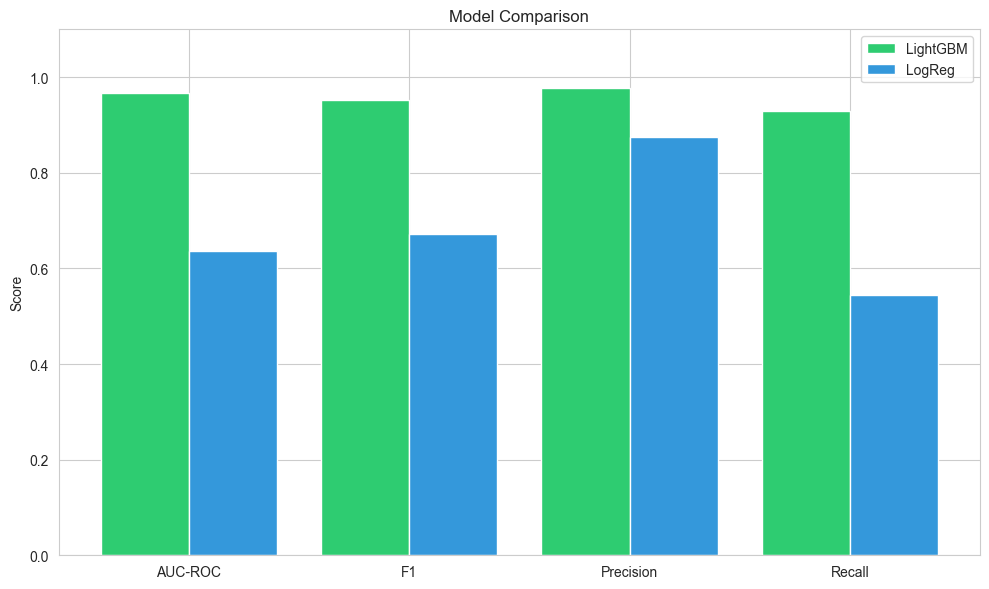

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(metrics))
ax.bar(x - 0.2, list(metrics.values()), 0.4, label="CatBoost", color="#2ecc71")
ax.bar(x + 0.2, list(baseline.values()), 0.4, label="LogReg", color="#3498db")
ax.set_xticks(x)
ax.set_xticklabels(metrics.keys())
ax.set_ylabel("Score")
ax.set_title("Model Comparison")
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

## Feature Importance

In [26]:
fi = pd.DataFrame(
    {"feature": X_train.columns, "importance": model.feature_importances_}
).sort_values("importance", ascending=False)
print(fi.head(20).to_string(index=False))

               feature  importance
           contact_LTV         169
      contact_age_days         105
               sale_ts          83
    contact_created_at          70
  lead_Трек-номер СДЭК          69
            lead_price          69
         contact_Город          66
             lead_tags          64
       lead_created_at          62
order_calculated_price          60
       contact_Код ПВЗ          59
       contact_Телефон          58
             lead_name          55
         lead_age_days          55
  lead_Служба доставки          51
              sale_day          43
     lead_Вес (грамм)*          43
  contact_Число сделок          39
             sale_hour          36
   lead_Тариф Доставки          30


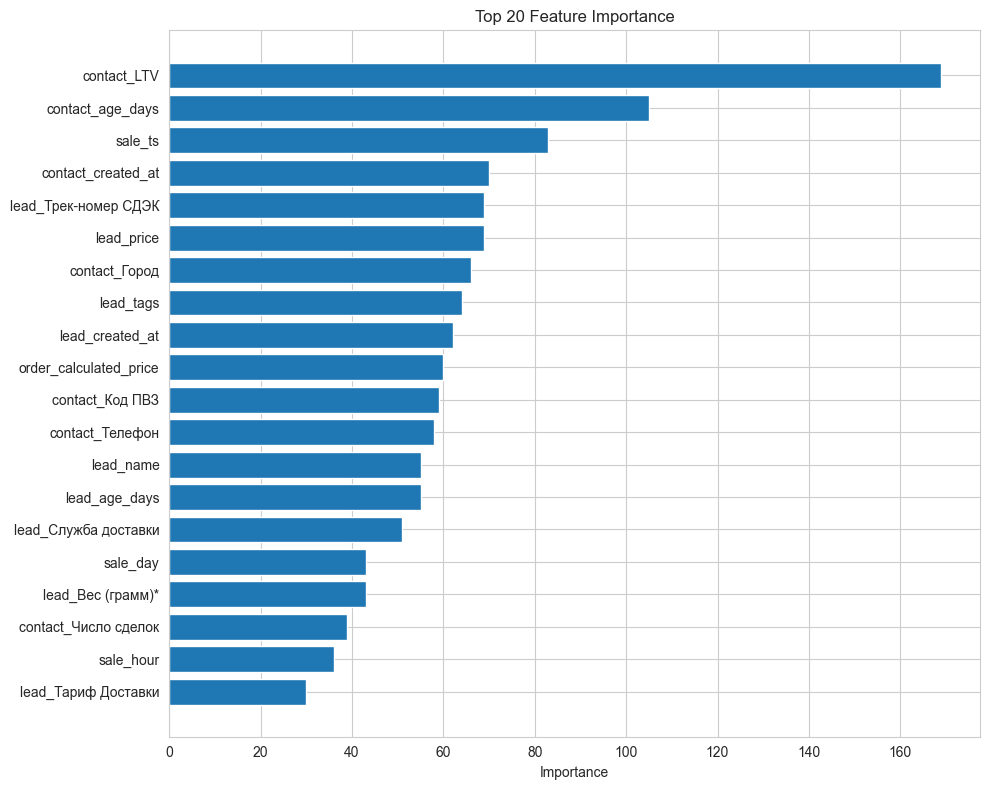

In [27]:
top = fi.head(20)
plt.figure(figsize=(10, 8))
plt.barh(range(20), top["importance"].values[::-1])
plt.yticks(range(20), top["feature"].values[::-1])
plt.xlabel("Importance")
plt.title("Top 20 Feature Importance")
plt.tight_layout()
plt.show()

## SHAP Analysis

In [28]:
explainer = shap.TreeExplainer(model)
sh = explainer.shap_values(X_test)
print(f"SHAP shape: {sh.shape}")

SHAP shape: (3435, 66)


c:\Соревнования\Артрейд\artrade\.venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: CatBoost binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


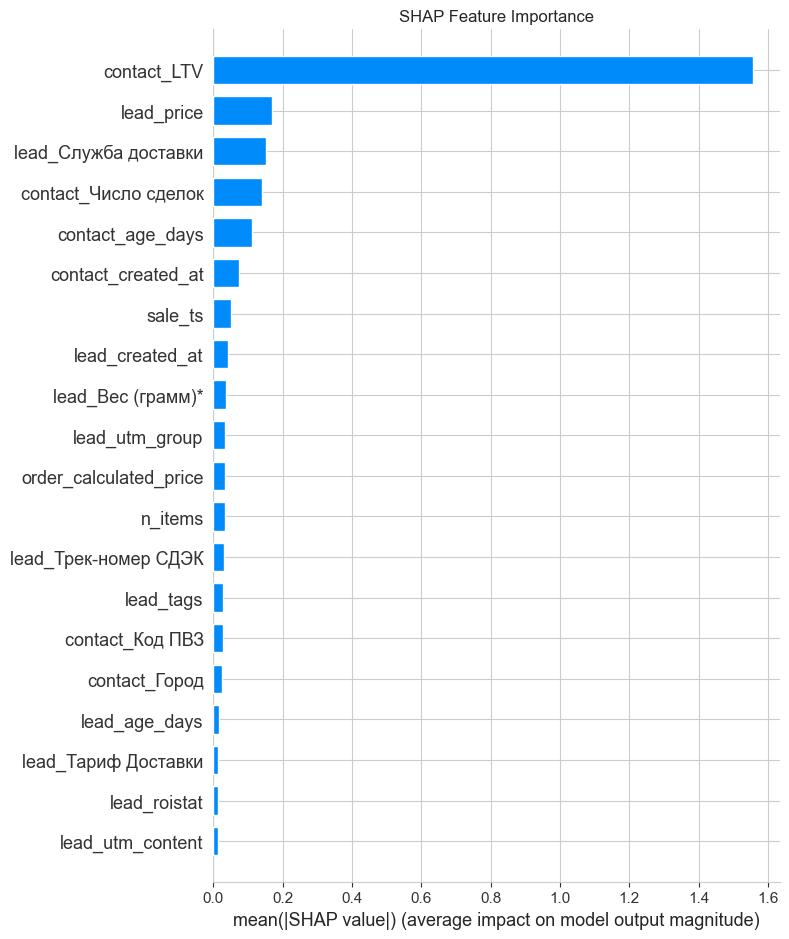

In [29]:
plt.figure(figsize=(12, 10))
shap.summary_plot(sh, X_test, plot_type="bar", show=False, max_display=20)
plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.show()

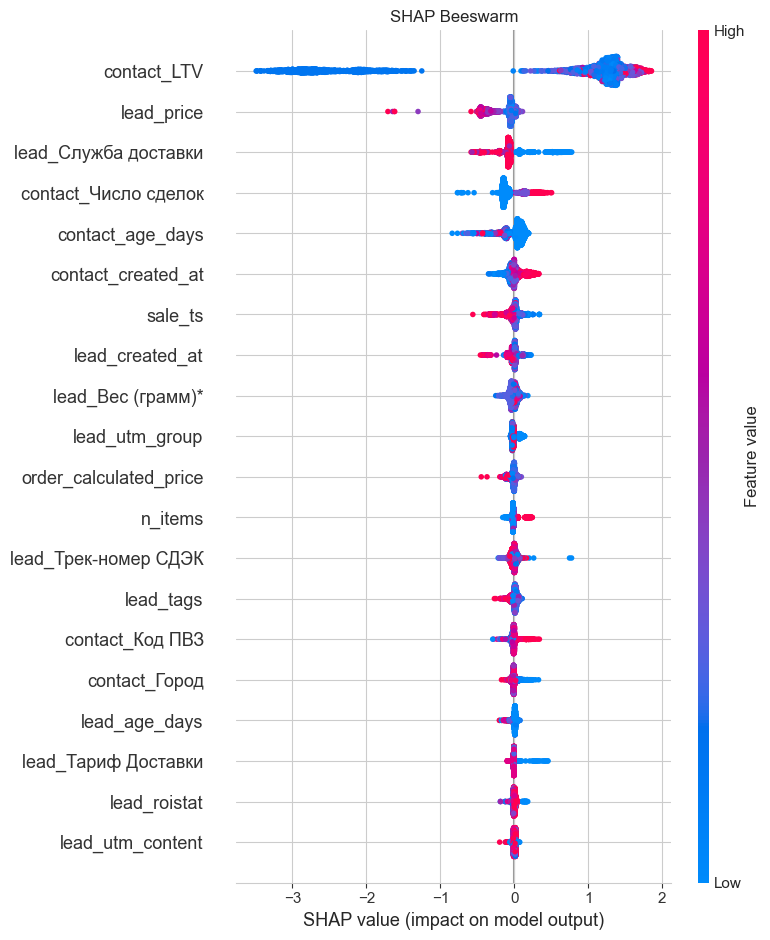

In [30]:
plt.figure(figsize=(12, 10))
shap.summary_plot(sh, X_test, show=False, max_display=20)
plt.title("SHAP Beeswarm")
plt.tight_layout()
plt.show()

## ROC Curve

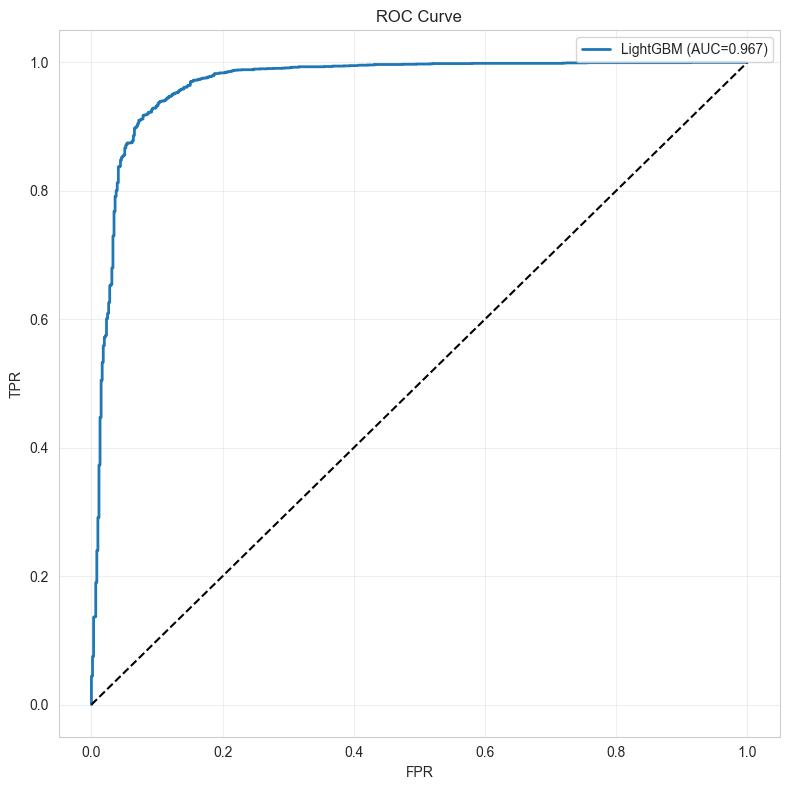

In [31]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, label=f"CatBoost (AUC={auc:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Confusion Matrix

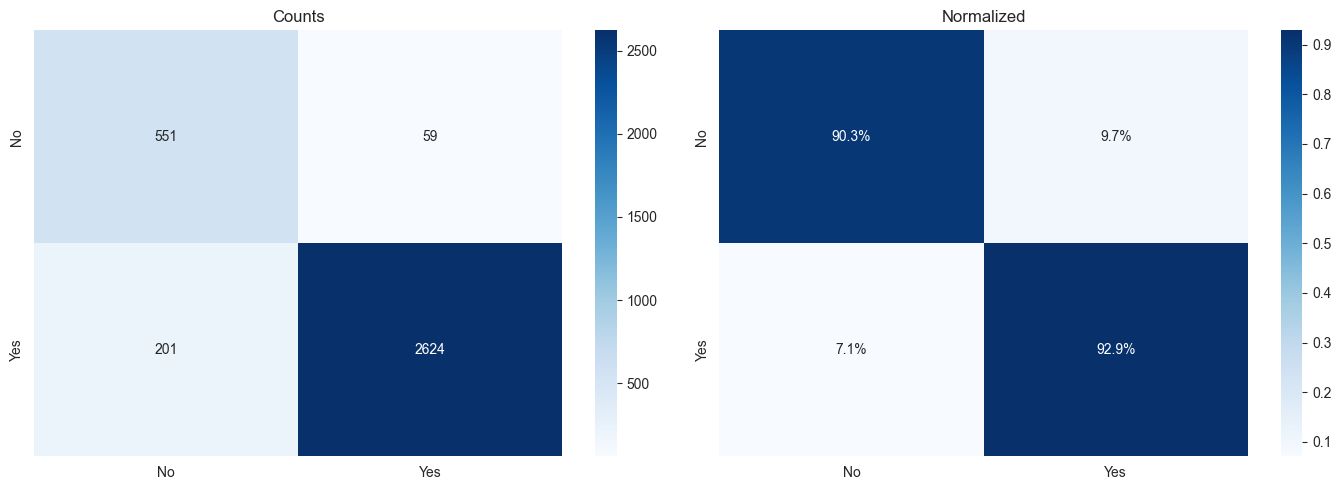

              precision    recall  f1-score   support

  Not Buyout       0.73      0.90      0.81       610
      Buyout       0.98      0.93      0.95      2825

    accuracy                           0.92      3435
   macro avg       0.86      0.92      0.88      3435
weighted avg       0.93      0.92      0.93      3435



In [32]:
cm = confusion_matrix(y_test, y_pred)
cm_n = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax[0],
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"],
)
ax[0].set_title("Counts")
sns.heatmap(
    cm_n,
    annot=True,
    fmt=".1%",
    cmap="Blues",
    ax=ax[1],
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"],
)
ax[1].set_title("Normalized")
plt.tight_layout()
plt.show()
print(classification_report(y_test, y_pred, target_names=["Not Buyout", "Buyout"]))

## Group Analysis

In [33]:
df_raw = pd.read_csv(RAW_DATA)
tr = df_raw.iloc[: len(y_test)].copy()
tr["y_true"] = y_test.values
tr["y_pred"] = y_pred
tr["y_proba"] = y_pred_proba

C:\Users\ASUS\AppData\Local\Temp\ipykernel_6252\2163139232.py:1: DtypeWarning: Columns (0: lead_Оплата МОП, 1: lead_Счет оплачен, 2: lead_Название товара, 3: lead_Наименование получателя, 4: lead_ФИО, 5: lead_Адрес доставки, 6: contact_TelegramId_WZ, 7: lead_СМС-уведомления, 8: contact_TelegramUsername_WZ, 9: lead_Объявление, 10: lead_URL объявления, 11: lead_Поиск товаров GoSklad, 12: lead_Список товаров GoSklad, 13: lead_Колесо, 14: contact_Канал Callibri, 15: lead_ROISTAT_REFERRER, 16: lead_Категория и варианты выбора, 17: lead_Ссылка на документ, 18: lead_Выбранные товары, 19: contact_Ссылка на документ, 20: lead_Solo, 21: lead_YBAIP, 22: lead_from, 23: lead_Source phone, 24: lead_ИМ сдэк, 25: lead_Комментарий к отправлению, 26: lead_POLICY, 27: lead_LEADQUALIFYCATION, 28: lead_ROISTAT_POS, 29: lead_ROISTAT_FIELDS_ROISTAT, 30: lead_ROISTAT_URL, 31: lead_TEST-TAG, 32: lead_BANNER-SIZES, 33: lead_CTIME, 34: lead_BANNER-TEST-TAGS, 35: lead_BANNERS-VIDEOS, 36: lead_CONSTRUCTOR-RENDERED

In [34]:
city = (
    tr.groupby("contact_Город")
    .agg({"y_true": ["mean", "count"], "y_proba": "mean"})
    .round(3)
)
city.columns = ["actual", "count", "predicted"]
city = city[city["count"] >= 10].sort_values("count", ascending=False)
print(city.head(15))

                 actual  count  predicted
contact_Город                            
Москва            0.800    461      0.706
Санкт-Петербург   0.828    163      0.720
Новосибирск       0.792     48      0.682
Пермь             0.897     39      0.812
Краснодар         0.939     33      0.784
Самара            0.788     33      0.699
Иркутск           0.839     31      0.723
Ярославль         0.889     27      0.726
Владивосток       0.808     26      0.759
Казань            0.920     25      0.770
Нижний Новгород   1.000     25      0.801
Тюмень            0.800     25      0.694
Екатеринбург      0.920     25      0.798
Волгоград         0.800     25      0.673
Уфа               0.920     25      0.765


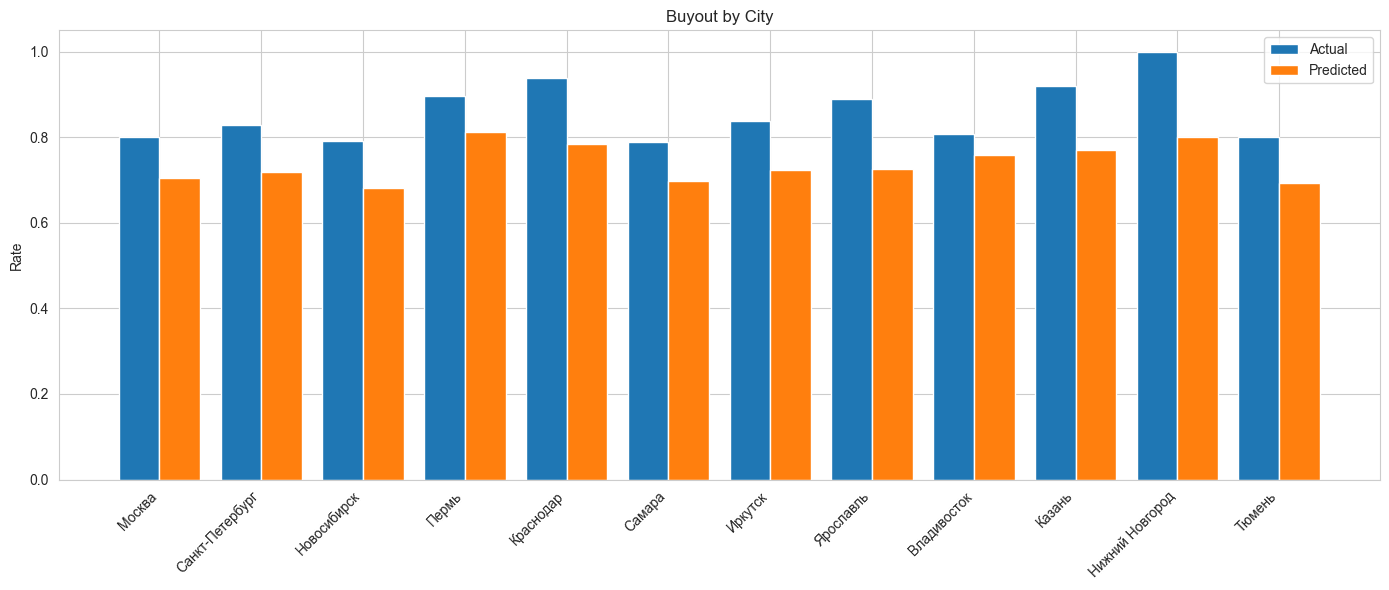

In [35]:
tc = city.head(12)
plt.figure(figsize=(14, 6))
x = np.arange(len(tc))
plt.bar(x - 0.2, tc["actual"], 0.4, label="Actual")
plt.bar(x + 0.2, tc["predicted"], 0.4, label="Predicted")
plt.xticks(x, tc.index, rotation=45, ha="right")
plt.ylabel("Rate")
plt.title("Buyout by City")
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
utm = (
    tr.groupby("lead_utm_source")
    .agg({"y_true": ["mean", "count"], "y_proba": "mean"})
    .round(3)
)
utm.columns = ["actual", "count", "predicted"]
utm = utm[utm["count"] >= 5].sort_values("count", ascending=False)
print(utm.head(15))

                          actual  count  predicted
lead_utm_source                                   
ppc_ru_yandex_art_npz      0.814   2316      0.720
Youtube                    1.000     13      0.816
yandex                     0.615     13      0.526
sma_ru_vkontakte_art_npz   0.778      9      0.620


## Threshold Analysis

In [37]:
thresholds = np.arange(0.1, 0.95, 0.05)
tres = []
for t in thresholds:
    yp = (y_pred_proba >= t).astype(int)
    tres.append(
        {
            "threshold": t,
            "precision": precision_score(y_test, yp, zero_division=0),
            "recall": recall_score(y_test, yp, zero_division=0),
            "f1": f1_score(y_test, yp, zero_division=0),
        }
    )
tdf = pd.DataFrame(tres)
print(tdf.to_string(index=False))

 threshold  precision   recall       f1
      0.10   0.942742 0.990796 0.966172
      0.15   0.960194 0.981947 0.970949
      0.20   0.960513 0.981593 0.970938
      0.25   0.960750 0.979115 0.969846
      0.30   0.962343 0.976991 0.969612
      0.35   0.967503 0.969558 0.968529
      0.40   0.970811 0.953628 0.962143
      0.45   0.975037 0.940177 0.957290
      0.50   0.978010 0.928850 0.952796
      0.55   0.980045 0.921416 0.949827
      0.60   0.981089 0.918230 0.948619
      0.65   0.982082 0.911858 0.945668
      0.70   0.983449 0.904425 0.942283
      0.75   0.984393 0.893097 0.936526
      0.80   0.987128 0.868673 0.924120
      0.85   0.990200 0.786903 0.876923
      0.90   0.993151 0.461947 0.630587


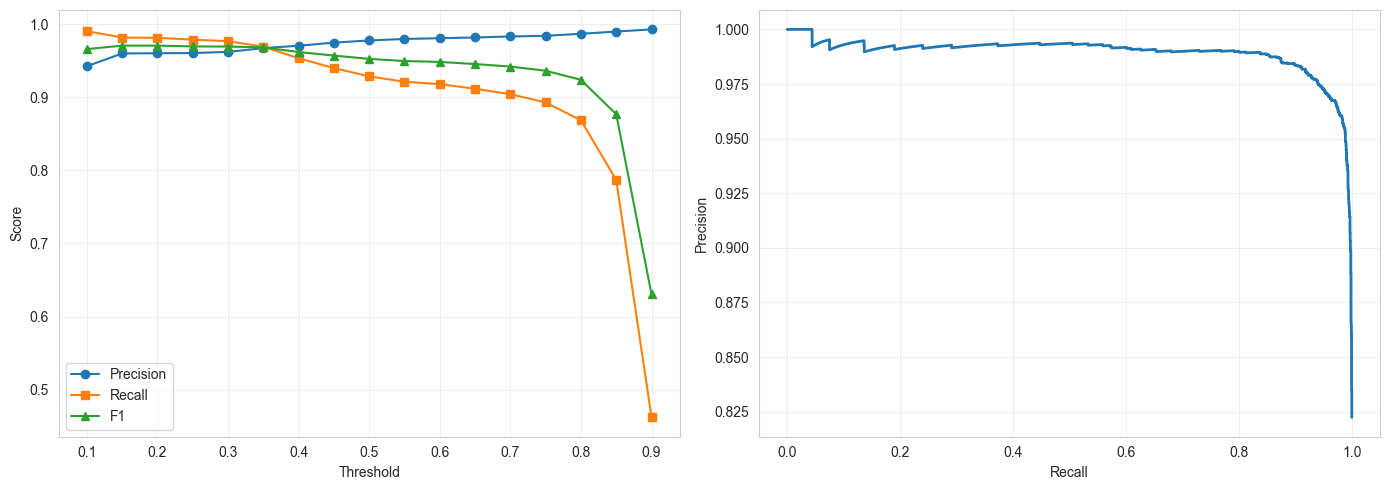

Best threshold: 0.15


In [38]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(tdf["threshold"], tdf["precision"], label="Precision", marker="o")
ax[0].plot(tdf["threshold"], tdf["recall"], label="Recall", marker="s")
ax[0].plot(tdf["threshold"], tdf["f1"], label="F1", marker="^")
ax[0].set_xlabel("Threshold")
ax[0].set_ylabel("Score")
ax[0].legend()
ax[0].grid(alpha=0.3)
p_curve, r_curve, _ = precision_recall_curve(y_test, y_pred_proba)
ax[1].plot(r_curve, p_curve, linewidth=2)
ax[1].set_xlabel("Recall")
ax[1].set_ylabel("Precision")
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()
best_t = tdf.loc[tdf["f1"].idxmax(), "threshold"]
print(f"Best threshold: {best_t:.2f}")

## Error Analysis

In [39]:
fp = tr[(tr["y_true"] == 0) & (tr["y_pred"] == 1)]
fn = tr[(tr["y_true"] == 1) & (tr["y_pred"] == 0)]
print(f"FP: {len(fp)}, FN: {len(fn)}")

FP: 59, FN: 201


In [40]:
print("Top FP:")
print(
    fp.sort_values("y_proba", ascending=False)[
        ["contact_Город", "lead_price", "y_proba"]
    ].head(10)
)

Top FP:
                                          contact_Город  lead_price   y_proba
1540                                             Москва        6525  0.932982
2538                               Глазов, удмуртс респ        3276  0.929399
1470                                          Астрахань        5200  0.923337
1065                                             Москва        6170  0.923294
1364         обл Ростовская, р-н Багаевский, х Кудинова         950  0.919689
2534                                            Ступино       21550  0.916846
2595                                             Москва        7520  0.913891
1928                                            Вологда        3240  0.908191
1670  161300, Российская Федерация, обл Вологодская,...        3490  0.901352
984                                     Санкт-Петербург       10800  0.895706


In [41]:
print("Top FN:")
print(
    fn.sort_values("y_proba", ascending=True)[
        ["contact_Город", "lead_price", "y_proba"]
    ].head(10)
)

Top FN:
                                          contact_Город  lead_price   y_proba
1849                                    Санкт Петербург        3239  0.058890
1130                                             Самара        3445  0.062772
1103      238420 Багратионовск, Калининградская область        3458  0.063476
1799                                    Нижний Новгород        7599  0.063633
2434                                             Москва        2819  0.066558
1349                                              Курск        3240  0.069231
2457                                             Москва        7330  0.069473
789   350053, край Краснодарский, г Краснодар, п Кол...        3240  0.071153
3255                                             Москва       12990  0.073110
2610                                               Тула        2250  0.075852
